 Feature engineering means create better features to improve model performance :

    1. Combining features e.g. Full_Name = First_Name + Last_Name
   
    2. Creating new features e.g. BMI = weight / height^2
    
    3. Extracting useful information e.g. extract title from Name, title from ticket
    
    4. Erasing unimportant columns



In [150]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
#scikit python library used in machine learning
#Classification models (logistic Regression, SVC,Linear SVC, Random Forest Classifier..)
#Regression models(logistic Regression, SVR, Ridge, Random Forest Regressor..)

In [151]:
test=pd.read_csv("test.csv")

In [152]:
train=pd.read_csv("train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [153]:
train.shape

(891, 12)

In [154]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [155]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [156]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [157]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [158]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

We should clean our data

Data Preprocessing:

Handle missing values (e.g., fill age using median or predictive imputation)

Encode categorical features (e.g., one-hot or label encoding for Sex, Embarked,Name,Ticket,cabin)

Scaling feature using StandardScaler, MinMaxScaler

In [159]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer#fill mised value with any number or median..
from sklearn.preprocessing import OneHotEncoder#convert string to binary vector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder

Label Encoding: Converts each unique category (string) into a unique integer, ex:

['red', 'green', 'blue'] → [2, 1, 0]

One-Hot Encoding: Converts each category into a binary vector (0s and 1s)

['red', 'green', 'blue'] →
red:   [1, 0, 0]
green: [0, 1, 0]
blue:  [0, 0, 1]


Before using OneHotEncoder or LabelEncoder, you must replace NaN (missing values) with something else — like the string "missing".

In [160]:
train['Cabin'] = train['Cabin'].fillna('Missing')
train['Cabin_letter'] = train['Cabin'].apply(lambda x: x[0])#to prevent high dimensionality so only apply label or onhot encoding for first letter
#For each value x in the Cabin column (which is now either a cabin string like 'C85' or 'Missing'), it takes the first character of that string
test['Cabin'] = test['Cabin'].fillna('Missing')
test['Cabin_letter'] = test['Cabin'].apply(lambda x: x[0])

Name,Sex and  Ticket are object columns, and raw text like that doesn’t help machine learning models directly. Here’s how to handle them using feature engineering

x: Braund, Mr. Owen Harris so x.split(',')[1].split('.')[0].strip() 

1. ['Braund','Mr.Owen Harris']

2. ['Mr','Owen Harris]

3. ['Mr']

4. Mr without spaces using strip

In [161]:
#Name we can extract title to prevent high dimensionality after on hot encoding
#sex apply onlabel encoding just 1 and 0 isntead of male and female
#ticket same thing
train['Title']=train['Name'].apply(lambda x:x.split(',')[1].split('.')[0].strip())
test['Title']=test['Name'].apply(lambda x:x.split(',')[1].split('.')[0].strip())


"AB./5 21171" → matches "AB./" and stops because next char is '5' (digit)

113803" → no match because it starts with digits

match.group(0) returns the exact matched string ex "AB./"

.replace('.', '').replace('/', '').strip()  returns AB without/ and . and spaces


In [162]:
import re#regukar expression finding or extracting from string
train['Ticket_prefix'] = train['Ticket'].apply(
    lambda x: re.match(r'([A-Za-z./]+)', x).group(0).replace('.', '').replace('/', '').strip() 
    if re.match(r'([A-Za-z./]+)', x) else 'missing'
)
test['Ticket_prefix'] = test['Ticket'].apply(
    lambda x: re.match(r'([A-Za-z./]+)', x).group(0).replace('.', '').replace('/', '').strip() 
    if re.match(r'([A-Za-z./]+)', x) else 'missing'
)


In [163]:
train.drop(columns=['Name','Cabin','PassengerId','Ticket'],inplace=True) 
test.drop(columns=['Name','Cabin','PassengerId','Ticket'],inplace=True) 

In [164]:
train['Sex'] = train['Sex'].map({'male': 1, 'female': 0})
test['Sex'] = test['Sex'].map({'male': 1, 'female': 0})


In [165]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1  # +1 counts the passenger themselves
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1
#Combines SibSp and Parch into a single feature:

In [166]:
# Drop original columns after creating FamilySize
train = train.drop(columns=['SibSp', 'Parch'])
test = test.drop(columns=['SibSp', 'Parch'])


In [167]:
age_imputer = SimpleImputer(strategy='median')
train['Age'] = age_imputer.fit_transform(train[['Age']])
test['Age'] = age_imputer.transform(test[['Age']])
#age has missing values so we fill it with median value before binning

In [168]:
bins = [0, 12, 18, 35, 60, 80]
labels = ['Child', 'Teen', 'Adult', 'MidAge', 'Senior']
train['AgeGroup'] = pd.cut(train['Age'], bins=bins, labels=labels)
test['AgeGroup'] = pd.cut(test['Age'], bins=bins, labels=labels)
#Bin Age into categories:


In [169]:
train = train.drop(columns=['Age'])
test = test.drop(columns=['Age'])


In [170]:
train.head()

,Survived,Pclass,Sex,Fare,Embarked,Cabin_letter,Title,Ticket_prefix,FamilySize,AgeGroup
0,0,3,1,7.2500,S,M,Mr,A,2,Adult
1,1,1,0,71.2833,C,C,Mrs,PC,2,MidAge
2,1,3,0,7.9250,S,M,Miss,STONO,1,Adult
3,1,1,0,53.1000,S,C,Mrs,missing,2,Adult
4,0,3,1,8.0500,S,M,Mr,missing,1,Adult


In [171]:
train.shape

(891, 10)

In [172]:
train.isnull().sum()

Survived         0
Pclass           0
Sex              0
Fare             0
Embarked         2
Cabin_letter     0
Title            0
Ticket_prefix    0
FamilySize       0
AgeGroup         0
dtype: int64

In [173]:
test.head()

,Pclass,Sex,Fare,Embarked,Cabin_letter,Title,Ticket_prefix,FamilySize,AgeGroup
0,3,1,7.8292,Q,M,Mr,missing,1,Adult
1,3,0,7.0000,S,M,Mrs,missing,2,MidAge
2,2,1,9.6875,Q,M,Mr,missing,1,Senior
3,3,1,8.6625,S,M,Mr,missing,1,Adult
4,3,0,12.2875,S,M,Mrs,missing,3,Adult


In [174]:
test.isnull().sum()

Pclass           0
Sex              0
Fare             1
Embarked         0
Cabin_letter     0
Title            0
Ticket_prefix    0
FamilySize       0
AgeGroup         0
dtype: int64

In [175]:

age=['Fare']
agetr=Pipeline(
    steps=[
       ("imputer",SimpleImputer(strategy='median')) 
    ]
)
# Embarked have Nans where cabin i solved it and fill nan before extracting first letter from it
embarked = ['Embarked']
embarktr = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onhot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Title, Cabin_letter and Ticket_prefix  clean
title_ticket_cabin= ['Title', 'Ticket_prefix', 'Cabin_letter', 'AgeGroup']

titletr = Pipeline([
    ('onhot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#pipeline takes steps [] and strategy (fill null value with?)

ColumnTransformer is like fit_transform() for multiple columns

Training (fit_transform): You study a textbook, take notes, and summarize what you learned.

Testing (transform only): You use what you learned to solve problems—without opening the textbook again.

In [176]:

colm=ColumnTransformer(
    transformers=[
        ('age',agetr,age),
        ('embarked',embarktr,embarked),
        ('rest',titletr,title_ticket_cabin),
        ('family', 'passthrough', ['FamilySize'])
        
    ]
)
#passthrough : Take this column as-is and pass it directly to the model without applying any transformation.

In [177]:
colm

ColumnTransformer(transformers=[('age',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Fare']),
                                ('embarked',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('onhot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Embarked']),
                                ('rest',
                                 Pipeline(steps=[('onhot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Title', 'Ticket_prefix', 'Cabin_letter',
                                  'AgeGroup']),
                                ('family', 'passthrough', ['FamilySize'])])

Try all algorithms to find best one

In [178]:
models={
    'SVC':SVC(),
    'LR':LogisticRegression(),
    'RandomForestClassifier':RandomForestClassifier(),
    'LSVC':LinearSVC(),
    'kNN':KNeighborsClassifier(),
    'XGBClassifier':XGBClassifier()
}

In [179]:
ytrain=train['Survived']
ytrain

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

Imbalanced Dataset

In [180]:
ytrain.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [181]:
xtrain=train.drop('Survived',axis=1)
xtrain

,Pclass,Sex,Fare,Embarked,Cabin_letter,Title,Ticket_prefix,FamilySize,AgeGroup
0,3,1,7.2500,S,M,Mr,A,2,Adult
1,1,0,71.2833,C,C,Mrs,PC,2,MidAge
2,3,0,7.9250,S,M,Miss,STONO,1,Adult
3,1,0,53.1000,S,C,Mrs,missing,2,Adult
4,3,1,8.0500,S,M,Mr,missing,1,Adult
...,...,...,...,...,...,...,...,...,...
886,2,1,13.0000,S,M,Rev,missing,1,Adult
887,1,0,30.0000,S,B,Miss,missing,1,Adult
888,3,0,23.4500,S,M,Miss,WC,4,Adult
889,1,1,30.0000,C,C,Mr,missing,1,Adult


In [182]:
xtrain.isnull().sum()

Pclass           0
Sex              0
Fare             0
Embarked         2
Cabin_letter     0
Title            0
Ticket_prefix    0
FamilySize       0
AgeGroup         0
dtype: int64

In [183]:
test.isnull().sum()

Pclass           0
Sex              0
Fare             1
Embarked         0
Cabin_letter     0
Title            0
Ticket_prefix    0
FamilySize       0
AgeGroup         0
dtype: int64

In [184]:
cleandata=colm.fit_transform(xtrain)
cleandata

array([[ 7.25  ,  0.    ,  0.    , ...,  0.    ,  0.    ,  2.    ],
       [71.2833,  1.    ,  0.    , ...,  0.    ,  0.    ,  2.    ],
       [ 7.925 ,  0.    ,  0.    , ...,  0.    ,  0.    ,  1.    ],
       ...,
       [23.45  ,  0.    ,  0.    , ...,  0.    ,  0.    ,  4.    ],
       [30.    ,  1.    ,  0.    , ...,  0.    ,  0.    ,  1.    ],
       [ 7.75  ,  0.    ,  1.    , ...,  0.    ,  0.    ,  1.    ]],
      shape=(891, 66))

22. is the Age

0., 1., 0. etc. are one-hot encoded values for Embarked, Cabin_letter, Title, Ticket_prefix, etc.

You started with fewer columns (like 11), and after OneHotEncoding, it became 60 columns due to many categories.

🔹 What Is .score()?
.score(X, y) in scikit-learn:

Trains the model (if not already trained).

Evaluates its performance (usually accuracy :percentage of correct predictions)

🔹 What Is Cross-Validation?
Cross-validation (especially k-fold cross-validation) is a more reliable performance evaluation method.

Example: 5-Fold Cross-Validation
The data is split into 5 equal parts.

The model is trained on 4 parts and tested on the 5th.

This is repeated 5 times, with a different fold as the test set each time.

Then the average accuracy is calculated.

Imagine you have 100 data points and want to check how good your model is.

Instead of just training your model on 80 data points and testing on 20 once (which might be lucky or unlucky),

Cross-validation does this:

Split the 100 data points into 5 groups of 20 (these are called “folds”).

Round 1:

Train the model on groups 1, 2, 3, and 4 (total 80 points).

Test the model on group 5 (20 points).

Save the accuracy.

Round 2:

Train on groups 1, 2, 3, and 5.

Test on group 4.

Save the accuracy.

Round 3:

Train on groups 1, 2, 4, and 5.

Test on group 3.

Save the accuracy.

Round 4:

Train on groups 1, 3, 4, and 5.

Test on group 2.

Save the accuracy.

Round 5:

Train on groups 2, 3, 4, and 5.

Test on group 1.

Save the accuracy.



In [185]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(cleandata, ytrain, test_size=0.2)

In [186]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((712, 66), (179, 66), (712,), (179,))

In [187]:
np.random.seed(42)
results={}
for modelname,model in models.items():
    model.fit(X_train,y_train)
    results[modelname]=model.score(X_val,y_val)
results
#.score for xtest and ytest how well the model generalize to new unseen data
#.score for xtrain and ytrain (how well the model learned the data)



c:\Users\asus\Desktop\Titanic-Survivors\test\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'SVC': 0.7318435754189944,
 'LR': 0.8100558659217877,
 'RandomForestClassifier': 0.7988826815642458,
 'LSVC': 0.8268156424581006,
 'kNN': 0.770949720670391,
 'XGBClassifier': 0.8212290502793296}

.score() method for classification models returns the accuracy of the model’s predictions on the dataset cleandata compared to the true labels ytrain.

Uses the model to predict labels for cleandata

Compares predictions with true ytrain

Calculates the accuracy (percentage of correct predictions)

Cross-validation (CV) is a statistical technique used to evaluate the performance of a machine learning

In [188]:
#aplly cv on full train data
from sklearn.model_selection import cross_val_score
np.random.seed(42)
results={}
for modelname,model in models.items():
    scores = cross_val_score(model, cleandata, ytrain, cv=5)#5 folds
    results[modelname]=scores.mean()
results
#the model sees both the training features (X_train) and their corresponding labels (y_train) — so it can learn from them.

#Then the model is tested on the held-out fold — where it only sees the features (X_test) and predicts labels.

#These predictions are compared to the true labels (y_test) to calculate accuracy (or other metrics).






c:\Users\asus\Desktop\Titanic-Survivors\test\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\asus\Desktop\Titanic-Survivors\test\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_

{'SVC': np.float64(0.6690101060824808),
 'LR': np.float64(0.8260247316552632),
 'RandomForestClassifier': np.float64(0.7979599522942691),
 'LSVC': np.float64(0.824913690289373),
 'kNN': np.float64(0.7576423325591615),
 'XGBClassifier': np.float64(0.8069612704789403)}

In [189]:
cleantest=colm.transform(test)

In [190]:
cleantest

array([[ 7.8292,  0.    ,  1.    , ...,  0.    ,  0.    ,  1.    ],
       [ 7.    ,  0.    ,  0.    , ...,  0.    ,  0.    ,  2.    ],
       [ 9.6875,  0.    ,  1.    , ...,  1.    ,  0.    ,  1.    ],
       ...,
       [ 7.25  ,  0.    ,  0.    , ...,  0.    ,  0.    ,  1.    ],
       [ 8.05  ,  0.    ,  0.    , ...,  0.    ,  0.    ,  1.    ],
       [22.3583,  1.    ,  0.    , ...,  0.    ,  0.    ,  3.    ]],
      shape=(418, 66))

Since LogisticRegression has the highest average cross-validation accuracy (~82%), it suggests LogisticRegression is the best performing model 

In [191]:
from sklearn.metrics import confusion_matrix,f1_score,precision_score,recall_score,classification_report,ConfusionMatrixDisplay

In [ ]:
# Fit the Logistic Regression model with class_weight='balanced'
lr_balanced = LogisticRegression(
    class_weight='balanced',  # handles imbalanced classes
    max_iter=1000,             # make sure it converges
    random_state=42
)

lr_balanced.fit(X_train, y_train)
y_pred = lr_balanced.predict(X_val)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))


[[92 24]
 [13 50]]
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       116
           1       0.68      0.79      0.73        63

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.81      0.79      0.80       179



Precision:(tells how many of the predicted positives were actually positive)

1. Class 0 (Unsurvived): 0.88 → Of all passengers predicted as unsurvived, 88% were truly unsurvived.

2. Class 1 (survived): 0.68  → Of  all passengers predicted  as survived , 86% were truly  survived

Recall:(tells how many of the actual positives were correctly predicted)

1. Class 0 (Unsurvived): 0.79 → Of  all passengers that are actually unsurvived , 79%  were predicted as unsurvived

2. Class 1 (survived): 0.79 →  Of all passengers that are actually survived, 79% were predicted as survived

✅ .precision_score(y_test, y_pred).... only for positive class .....TP/TP+FP

✅ .recall_score(y_test, y_pred)...only for positive class (survived)....TP/TP+FN

✅classification report view for positive and negative class.

In [208]:
from collections import Counter

# Calculate ratio
ratio = Counter(y_train)[0] / Counter(y_train)[1]

xgb_balanced = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,   # handle imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_balanced.fit(X_train, y_train)

# Evaluate
y_pred = xgb_balanced.predict(X_val)

from sklearn.metrics import classification_report, confusion_matrix
cfm= confusion_matrix(y_val, y_pred)
print(cfm)
print(classification_report(y_val, y_pred))

c:\Users\asus\Desktop\Titanic-Survivors\test\lib\site-packages\xgboost\training.py:183: UserWarning: [02:21:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[[98 18]
 [16 47]]
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       116
           1       0.72      0.75      0.73        63

    accuracy                           0.81       179
   macro avg       0.79      0.80      0.79       179
weighted avg       0.81      0.81      0.81       179



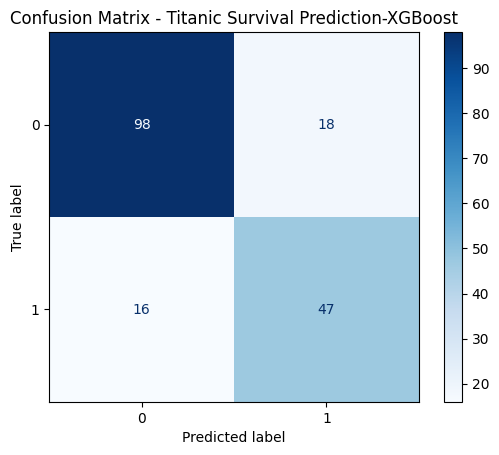

<Figure size 640x480 with 0 Axes>

In [210]:
# TN are actually negative(unsurvived) and detected as negative
# FP are actualyy negative and detected as positive
# FN are actually positive(survived) and detected as negative (unsurvived)
# TP are actually positive and detected as positive 
disp = ConfusionMatrixDisplay(confusion_matrix=cfm)

disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Titanic Survival Prediction-XGBoost")
plt.show()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')

In [194]:
#Hyperparameer tunning tool used to find best settings or best parameters of ML model that should be set before training to improve performance and minimize error.
from sklearn.model_selection import GridSearchCV

In [195]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # works with l1 and l2
}

In [196]:
tunning = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)
tunning.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000, random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy')

In [197]:
best=tunning.best_params_

In [198]:
best

{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

In [199]:
LR_final = LogisticRegression(**best,class_weight='balanced',max_iter=1000,random_state=42)
LR_final.fit(X_train, y_train)

#Evaluate on validation set
y_val_pred = LR_final.predict(X_val)


In [200]:
y_val_pred

array([0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0])

In [201]:
y_val

570    1
709    1
28     1
287    0
278    0
      ..
249    0
162    0
171    0
401    0
81     1
Name: Survived, Length: 179, dtype: int64

In [202]:
cf=confusion_matrix(y_val_pred,y_val)
cf

array([[93, 13],
       [23, 50]])

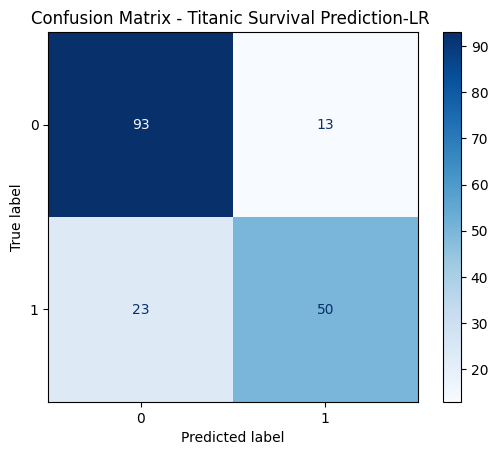

<Figure size 640x480 with 0 Axes>

In [211]:

# TN are actually negative(unsurvived) and detected as negative
# FP are actualyy negative and detected as positive
# FN are actually positive(survived) and detected as negative (unsurvived)
# TP are actually positive and detected as positive 
disp = ConfusionMatrixDisplay(confusion_matrix=cf)

disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Titanic Survival Prediction-LR ")
plt.show()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')

In [204]:
print(classification_report(y_val_pred,y_val))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       106
           1       0.79      0.68      0.74        73

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [205]:
report=classification_report(y_val_pred,y_val)
report


'              precision    recall  f1-score   support\n\n           0       0.80      0.88      0.84       106\n           1       0.79      0.68      0.74        73\n\n    accuracy                           0.80       179\n   macro avg       0.80      0.78      0.79       179\nweighted avg       0.80      0.80      0.80       179\n'

In [206]:
ytest=LR_final.predict(cleantest)

In [207]:
ytest

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,